# Reduced Gaussian grids: ERA5 on O96 and N320
---

ECMWF's forecasts (IFS), the ERA5 reanalysis and the AIFS machine-learning models
use **reduced Gaussian grids**: latitude rows at the Gaussian quadrature latitudes,
with fewer longitude points per row towards the poles. Two families exist:

* **classical `N` grids** — e.g. **N320**, the native ERA5 grid (542 080 points); the
  points per row follow ECMWF tables,
* **octahedral `O` grids** — e.g. **O96** (40 320 points, ~1°); row `j` from the pole
  has `4·j + 16` points.

Data on such a grid is a 1-D array in *storage order*: rows from north to south, each
row from west to east starting at 0° longitude — the `values` dimension of a GRIB
message. `ReducedGaussianFilter` triangulates the points on the sphere and filters them
as mesh nodes, with spherical tangent-plane geometry that needs no special treatment at
the poles or the date line.

This notebook uses two public datasets that need no registration:

* **ERA5 on O96** from ECMWF's Anemoi training dataset (6-hourly, 1979–2023,
  [CC-BY-4.0](https://www.ecmwf.int/en/newsletter/185/news/anemoi-training-ready-version-era5-now-open-all),
  contains Copernicus Climate Change Service information),
* **ERA5 on its native N320 grid** from Google Research's
  [ARCO-ERA5](https://github.com/google-research/arco-era5) (hourly, 1979–2021;
  Copernicus ERA5 redistributed by Google — contains modified Copernicus Climate Change
  Service information, used under the Copernicus licence).

Requirements beyond `implicit_filter`: `zarr`, `fsspec` with HTTP support (`aiohttp`),
`matplotlib`. Both stores are read over plain HTTPS; one time step is 16 MB (O96) or
2 MB per field (N320).

In [1]:
import warnings

# a Jupyter widgets warning from a dependency, not from implicit_filter
warnings.filterwarnings("ignore", message="IProgress not found")

import json
import math
import time
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import zarr

from implicit_filter import ReducedGaussianFilter, reduced_gaussian_grid

## The O96 grid
---

`reduced_gaussian_grid` returns the coordinates of every point of a named grid in
storage order. No data is needed to build the filter for a named grid.

O96: 40320 points on 192 latitude rows; first row at 89.284° with 20 points


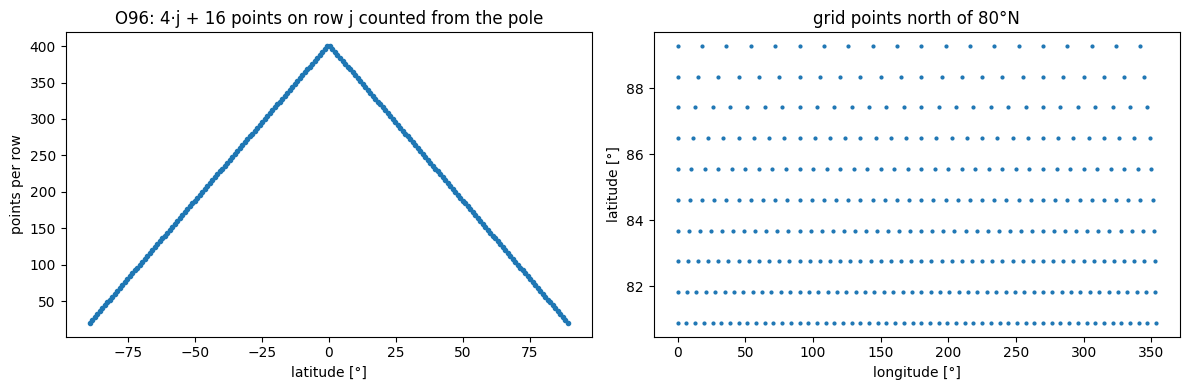

In [2]:
lat_o96, lon_o96 = reduced_gaussian_grid("O96")
rows, points_per_row = np.unique(lat_o96, return_counts=True)
rows, points_per_row = rows[::-1], points_per_row[::-1]   # north to south, as stored
print(f"O96: {lat_o96.size} points on {rows.size} latitude rows; "
      f"first row at {lat_o96[0]:.3f}° with {points_per_row[0]} points")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(rows, points_per_row, ".")
ax[0].set_xlabel("latitude [°]")
ax[0].set_ylabel("points per row")
ax[0].set_title("O96: 4·j + 16 points on row j counted from the pole")
north = lat_o96 > 80.0
ax[1].scatter(lon_o96[north], lat_o96[north], s=4)
ax[1].set_xlabel("longitude [°]")
ax[1].set_ylabel("latitude [°]")
ax[1].set_title("grid points north of 80°N")
plt.tight_layout()

## ERA5 on O96 from ECMWF's Anemoi dataset
---

The store is a zarr v2 group: `data[time, variable, ensemble, point]`, `dates`,
`latitudes`, `longitudes`, and the variable names in the root attributes.

In [3]:
O96_URL = "https://data.ecmwf.int/anemoi-datasets/era5-o96-1979-2023-6h-v8.zarr"

with urllib.request.urlopen(O96_URL + "/.zattrs") as response:
    o96_attrs = json.load(response)
variables = o96_attrs["variables"]
print(o96_attrs["resolution"], o96_attrs["frequency"], o96_attrs["start_date"], "to",
      o96_attrs["end_date"], "| licence:", o96_attrs["licence"])
print(len(variables), "variables, surface ones:", [v for v in variables if "_" not in v])

# zarr v2 store; zarr >= 3 detects the format (older zarr 3 releases may need zarr_format=2)
dates = zarr.open_array(O96_URL + "/dates", mode="r")[:]
store_lat = zarr.open_array(O96_URL + "/latitudes", mode="r")[:]
store_lon = zarr.open_array(O96_URL + "/longitudes", mode="r")[:]
assert np.allclose(store_lat, lat_o96) and np.allclose(store_lon, lon_o96)
print("The store's coordinates match reduced_gaussian_grid('O96') point for point.")

O96 6h 1979-01-01T00:00:00 to 2023-12-31T18:00:00 | licence: CC-BY-4.0/CDS
101 variables, surface ones: ['10u', '10v', '2d', '2t', 'cp', 'insolation', 'lsm', 'msl', 'sdor', 'skt', 'slor', 'sp', 'tcw', 'tp', 'z']


The store's coordinates match reduced_gaussian_grid('O96') point for point.


In [4]:
data_o96 = zarr.open_array(O96_URL + "/data", mode="r")
when = np.datetime64("2020-01-01T00:00:00")
it = int(np.searchsorted(dates, when))
assert dates[it] == when

t0 = time.time()
snapshot = data_o96[it, :, 0, :]              # (variables, points): one 16 MB chunk
print(f"read {snapshot.shape} in {time.time() - t0:.1f} s")

t2m_o96 = snapshot[variables.index("2t")].astype(float)
u10_o96 = snapshot[variables.index("10u")].astype(float)
v10_o96 = snapshot[variables.index("10v")].astype(float)

read (101, 40320) in 1.5 s


## Prepare the filter
---

`prepare_from_grid` triangulates the 40 320 points and assembles the operator. Like
every filter in the package the result can be cached with `save_to_file` and reloaded
with `load_from_file`, so this is done once per grid. The cache files are written into
the working directory and are not small: 20 MB for O96 and 257 MB for N320 below.

In [5]:
flt_o96 = ReducedGaussianFilter()
t0 = time.time()
flt_o96.prepare_from_grid("O96")
print(f"O96 filter prepared in {time.time() - t0:.1f} s "
      f"({lat_o96.size} nodes, {2 * lat_o96.size - 4} triangles)")

flt_o96.save_to_file("o96_filter_cache")           # writes o96_filter_cache.npz
flt_o96 = ReducedGaussianFilter.load_from_file("o96_filter_cache.npz")

O96 filter prepared in 3.2 s (40320 nodes, 80636 triangles)


## Low-pass and high-pass filtering of 2 m temperature
---

As everywhere in the package the filter scale is passed as the wavenumber
`k = 2π / L` with `L` in kilometres. The high-pass field is the difference between the
data and its low-pass.

filtered 40320 points at 1000 km in 1.71 s


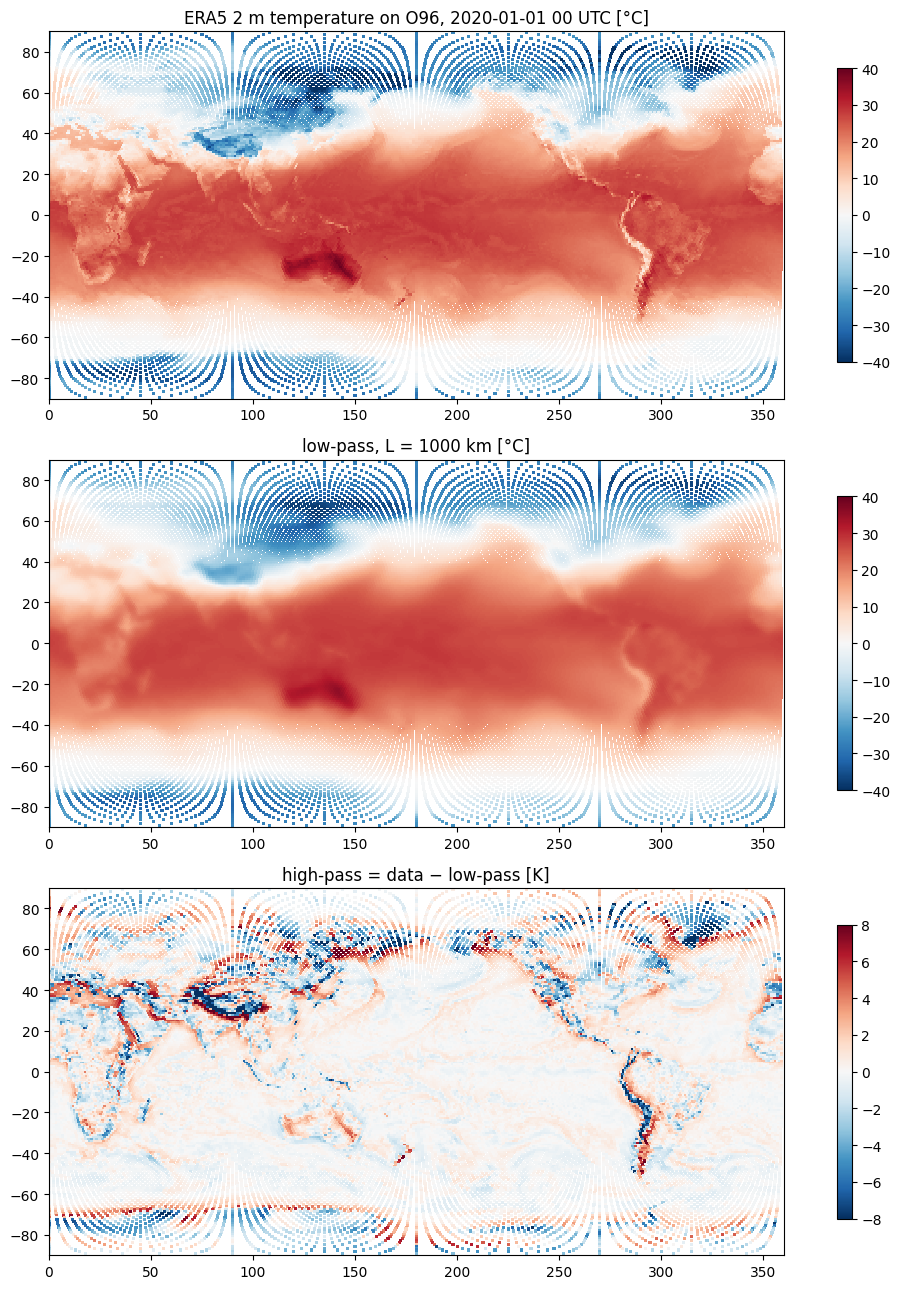

In [6]:
def plot_field(ax, lon, lat, values, title, cmap="viridis", vmin=None, vmax=None, s=5):
    sc = ax.scatter(lon, lat, c=values, s=s, cmap=cmap, vmin=vmin, vmax=vmax,
                    marker="s", linewidths=0)
    ax.set_xlim(0, 360)
    ax.set_ylim(-90, 90)
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, shrink=0.8)
    return sc


scale_km = 1000.0
k = 2 * math.pi / scale_km

t0 = time.time()
t2m_low = flt_o96.compute(1, k, t2m_o96)
print(f"filtered {t2m_o96.size} points at {scale_km:.0f} km in {time.time() - t0:.2f} s")
t2m_high = t2m_o96 - t2m_low

fig, ax = plt.subplots(3, 1, figsize=(11, 13))
plot_field(ax[0], lon_o96, lat_o96, t2m_o96 - 273.15,
           "ERA5 2 m temperature on O96, 2020-01-01 00 UTC [°C]", cmap="RdBu_r", vmin=-40, vmax=40)
plot_field(ax[1], lon_o96, lat_o96, t2m_low - 273.15,
           f"low-pass, L = {scale_km:.0f} km [°C]", cmap="RdBu_r", vmin=-40, vmax=40)
plot_field(ax[2], lon_o96, lat_o96, t2m_high,
           "high-pass = data − low-pass [K]", cmap="RdBu_r", vmin=-8, vmax=8)
plt.tight_layout()

## Filtering a vector field
---

`compute_velocity` filters the two components of the 10 m wind together (the
metric terms that couple them are off by default, as for every filter class).

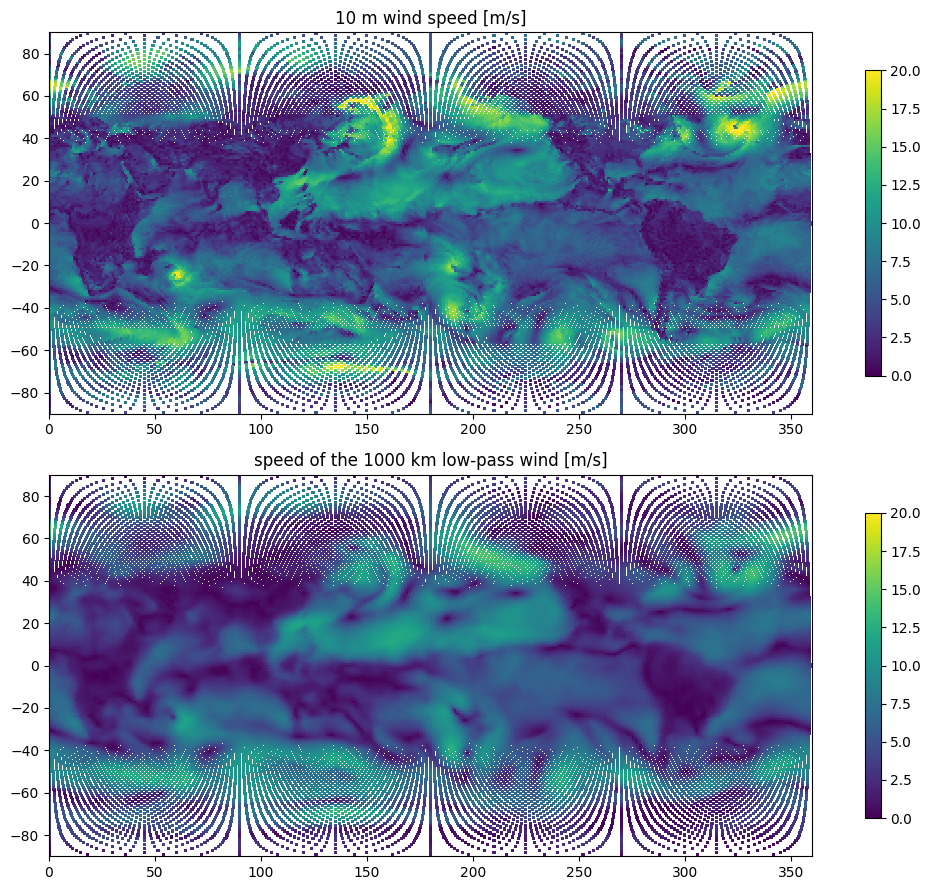

In [7]:
u_low, v_low = flt_o96.compute_velocity(1, k, u10_o96, v10_o96)
speed = np.hypot(u10_o96, v10_o96)
speed_low = np.hypot(u_low, v_low)

fig, ax = plt.subplots(2, 1, figsize=(11, 9))
plot_field(ax[0], lon_o96, lat_o96, speed, "10 m wind speed [m/s]", vmin=0, vmax=20)
plot_field(ax[1], lon_o96, lat_o96, speed_low,
           f"speed of the {scale_km:.0f} km low-pass wind [m/s]", vmin=0, vmax=20)
plt.tight_layout()

## ERA5 on its native N320 grid (ARCO-ERA5)
---

The `co/` stores of ARCO-ERA5 keep ERA5 on its native N320 grid: every field is a
`[time, values]` array with 1-D `latitude`/`longitude` coordinates. That is exactly
what `prepare_from_data_array` reads — the same call works for a GRIB file opened with
`xr.open_dataset(path, engine="cfgrib")`.

In [8]:
N320_URL = "https://storage.googleapis.com/gcp-public-data-arco-era5/co/single-level-reanalysis.zarr"

# zarr v2 store; zarr >= 3 detects the format (older zarr 3 releases may need zarr_format=2)
era5 = xr.open_zarr(N320_URL, consolidated=True, chunks=None)

snap = era5.sel(time="2020-01-01T00:00")
lat_n320 = era5.latitude.values
lon_n320 = era5.longitude.values
grid_lat, grid_lon = reduced_gaussian_grid("N320")
assert np.allclose(lat_n320, grid_lat) and np.allclose(lon_n320, grid_lon)
print("The store's coordinates match reduced_gaussian_grid('N320') point for point.")

t0 = time.time()
t2m_n320 = snap.t2m.values.astype(float)
sst_n320 = snap.sst.values.astype(float)
print(f"read two N320 fields ({lat_n320.size} points each) in {time.time() - t0:.1f} s; "
      f"{np.isnan(sst_n320).mean():.0%} of the SST points are land (NaN)")

The store's coordinates match reduced_gaussian_grid('N320') point for point.


read two N320 fields (542080 points each) in 1.2 s; 29% of the SST points are land (NaN)


In [9]:
flt_n320 = ReducedGaussianFilter()
t0 = time.time()
flt_n320.prepare_from_data_array(era5)          # uses the 1-D latitude/longitude coordinates
print(f"N320 filter prepared in {time.time() - t0:.0f} s")
flt_n320.save_to_file("n320_filter_cache")

N320 filter prepared in 32 s


## Masked data: sea surface temperature
---

SST is undefined over land. Passing `mask=` (True where the data is valid) removes the
land points from the operator: they are returned unchanged and the ocean points see a
no-flux boundary at the coast. NaNs must be replaced by a neutral value before
filtering: with NaN in the input the conjugate-gradient solver stops at its first
iteration and returns the data unchanged, so the filter would silently do nothing.

In [10]:
ocean = ~np.isnan(sst_n320)

flt_sst = ReducedGaussianFilter()
t0 = time.time()
flt_sst.prepare_from_points(lat_n320, lon_n320, mask=ocean)
print(f"N320 masked filter prepared in {time.time() - t0:.0f} s")

sst_filled = np.where(ocean, sst_n320, 0.0)
sst_scale_km = 500.0                           # `scale_km` above stays the 1000 km of the 2 m temperature section
t0 = time.time()
sst_low = flt_sst.compute(1, 2 * math.pi / sst_scale_km, sst_filled)
print(f"filtered {ocean.sum()} ocean points at {sst_scale_km:.0f} km "
      f"in {time.time() - t0:.0f} s")
sst_low[~ocean] = np.nan                       # re-apply the mask for plotting
sst_high = sst_n320 - sst_low

N320 masked filter prepared in 31 s


filtered 384934 ocean points at 500 km in 10 s


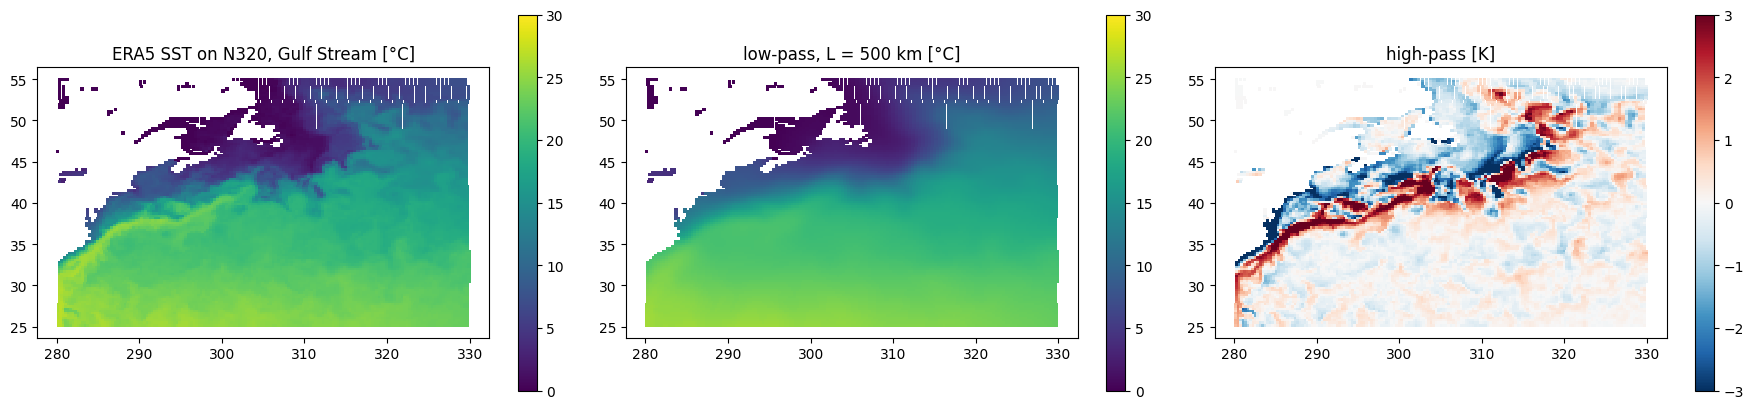

In [11]:
region = (lon_n320 > 280) & (lon_n320 < 330) & (lat_n320 > 25) & (lat_n320 < 55)


def plot_region(ax, values, title, cmap, vmin, vmax):
    sc = ax.scatter(lon_n320[region], lat_n320[region], c=values[region], s=6, cmap=cmap,
                    vmin=vmin, vmax=vmax, marker="s", linewidths=0)
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, shrink=0.8)


fig, ax = plt.subplots(1, 3, figsize=(18, 5))
plot_region(ax[0], sst_n320 - 273.15, "ERA5 SST on N320, Gulf Stream [°C]", "viridis", 0, 30)
plot_region(ax[1], sst_low - 273.15, f"low-pass, L = {sst_scale_km:.0f} km [°C]", "viridis", 0, 30)
plot_region(ax[2], sst_high, "high-pass [K]", "RdBu_r", -3, 3)
plt.tight_layout()

## Spectra
---

`compute_spectra_scalar` filters the data at a list of scales and returns the
area-weighted variance of the removed part for each scale (element 0 is the
area-weighted mean square of the data itself). Each additional scale is one more solve,
warm-started from the previous one.
Larger scales make the default Jacobi-CG solver slow, because the condition number of
the operator grows like (L/Δx)²; for those, `flt.set_preconditioner("vcycle")` (needs
`pip install "implicit_filter[vcycle]"`, see the V-cycle section of the readme) solves
the system in tens of iterations.

6 filter passes on N320 in 173 s


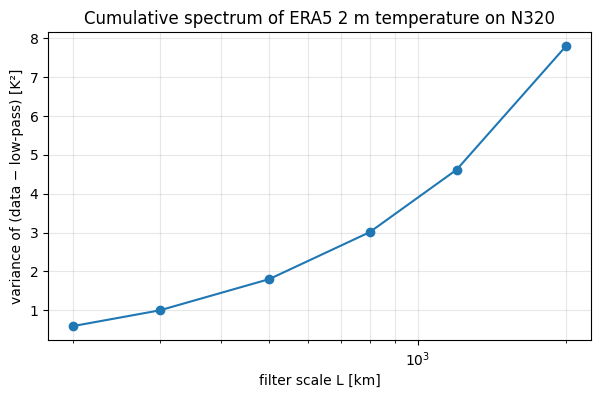

In [12]:
scales_km = np.array([200.0, 300.0, 500.0, 800.0, 1200.0, 2000.0])
kc = 2 * math.pi / scales_km

t0 = time.time()
spectra = flt_n320.compute_spectra_scalar(1, kc, t2m_n320)
print(f"{len(kc)} filter passes on N320 in {time.time() - t0:.0f} s")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(scales_km, spectra[1:], "o-")
ax.set_xscale("log")
ax.set_xlabel("filter scale L [km]")
ax.set_ylabel("variance of (data − low-pass) [K²]")
ax.set_title("Cumulative spectrum of ERA5 2 m temperature on N320")
ax.grid(True, which="both", alpha=0.3)

## Notes
---

* **GPU**: call `flt.set_backend("gpu")` before the first `compute` (see the readme);
  on the CPU host used for this run the N320 filter prepared in ~30 s, the masked
  500 km SST solve took ~10 s and the six spectra passes ~3 minutes in total.
* **Caching**: `prepare` is dominated by mesh topology and takes ~30 s for N320;
  `save_to_file` / `load_from_file` avoid repeating it.
* **GRIB files**: `flt.prepare_from_file("era5.grib", engine="cfgrib")` reads the
  coordinates cfgrib exposes for a reduced Gaussian grid.
* **Other grids**: any `O<N>` grid and the 16 classical grids ecCodes ships
  definitions for (N32 to N2000) are available by name; any other set of points
  covering the sphere works through `prepare_from_points`.
* **Limitations**: element (triangle-centre) filtering is not available for these
  meshes (the data is nodal); the metric-term coupled system (`full=True`) is singular
  near the poles, as on every spherical mesh.